In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [ ]:
! conda install pytorch=1.1.0 torchvision -c pytorch -y

Channels:
 - pytorch
 - conda-forge
Platform: linux-64
Solving environment: - \ | / - failed

PackagesNotFoundError: The following packages are not available from current channels:

  - pytorch=1.1.0*

Current channels:

  - https://conda.anaconda.org/pytorch
  - https://conda.anaconda.org/conda-forge

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [ ]:
!git clone https://github.com/pedropro/TACO.git
!cd TACO

# Install COCO tools
!pip install pycocotools

fatal: destination path 'TACO' already exists and is not an empty directory.


In [1]:
!git clone https://github.com/pedropro/TACO.git


Cloning into 'TACO'...
remote: Enumerating objects: 740, done.
remote: Counting objects: 100% (435/435), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 740 (delta 416), reused 380 (delta 380), pack-reused 305 (from 1)
Receiving objects: 100% (740/740), 97.48 MiB | 21.62 MiB/s, done.
Resolving deltas: 100% (499/499), done.


In [ ]:
!unzip taco_dataset.zip -d taco_dataset


unzip:  cannot find or open taco_dataset.zip, taco_dataset.zip.zip or taco_dataset.zip.ZIP.


In [ ]:
df = pd.read_csv('TACO/data/all_image_urls.csv', header=None)
print(df.head())



                                                   0  \
0  https://farm66.staticflickr.com/65535/33978196...   
1  https://farm66.staticflickr.com/65535/47803331...   
2  https://farm66.staticflickr.com/65535/40888872...   
3  https://farm66.staticflickr.com/65535/47803331...   
4  https://farm66.staticflickr.com/65535/33978199...   

                                                   1  
0  https://farm66.staticflickr.com/65535/33978196...  
1  https://farm66.staticflickr.com/65535/47803331...  
2  https://farm66.staticflickr.com/65535/40888872...  
3  https://farm66.staticflickr.com/65535/47803331...  
4  https://farm66.staticflickr.com/65535/33978199...  


import os
import pandas as pd
import urllib.request

df = pd.read_csv('TACO/data/all_image_urls.csv', header=None)
save_dir = 'images'
os.makedirs(save_dir, exist_ok=True)

for idx, row in df.iterrows():
    for col in [0, 1]:  # both columns have URLs
        img_url = row[col]
        filename = os.path.join(save_dir, f'image_{idx}_{col}.jpg')
        if not os.path.exists(filename):
            try:
                urllib.request.urlretrieve(img_url, filename)
            except:
                print(f'Failed to download {filename}')


#Experiments

In [ ]:
import os
import pandas as pd
import urllib.request

df = pd.read_csv('TACO/data/all_image_urls.csv', header=None)
save_dir = 'images'
os.makedirs(save_dir, exist_ok=True)

N_IMAGES = 500
downloaded_images = []

for idx, row in df.iterrows():
    for col in [0, 1]:
        img_url = row[col]
        filename = f'image_{idx}_{col}.jpg'
        filepath = os.path.join(save_dir, filename)

        if not os.path.exists(filepath):
            try:
                urllib.request.urlretrieve(img_url, filepath)
                downloaded_images.append(filename)
                print(f'Downloaded: {filename}')
            except:
                print(f'Failed to download: {filename}')
        if len(downloaded_images) >= N_IMAGES:
            break
    if len(downloaded_images) >= N_IMAGES:
        break


In [ ]:
import json

with open('TACO/data/annotations.json') as f:
    annotations = json.load(f)

downloaded_set = set(downloaded_images)

filtered_images = [img for img in annotations['images'] if img['file_name'] in downloaded_set]
filtered_image_ids = set(img['id'] for img in filtered_images)
filtered_annotations = [ann for ann in annotations['annotations'] if ann['image_id'] in filtered_image_ids]

filtered_data = {
    'images': filtered_images,
    'annotations': filtered_annotations,
    'categories': annotations['categories']
}

os.makedirs('filtered_data', exist_ok=True)
with open('filtered_data/annotations_filtered.json', 'w') as f:
    json.dump(filtered_data, f)

print(f"Filtered annotations saved to filtered_data/annotations_filtered.json")


In [ ]:
import torch
class WasteCocoDataset(torch.utils.data.Dataset):
    def __init__(self, root, annotation, transforms=None):
        self.root = root
        self.coco = COCO(annotation)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])
        img = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []

        for ann in anns:
            xmin, ymin, width, height = ann['bbox']
            xmax = xmin + width
            ymax = ymin + height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id])
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)


In [ ]:
from pycocotools.coco import COCO
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

img_root = 'subset_images'
ann_file = 'subset_annotations.json'


dataset = WasteCocoDataset(img_root, ann_file, transforms=ToTensor())
print(f"Total images in dataset: {len(dataset)}")
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Total images in dataset: 500


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = len(annotations['categories']) + 1
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:02<00:00, 64.8MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
num_epochs = 20
best_loss = float('inf')

for epoch in range(num_epochs, num_epochs):
    model.train()
    total_loss = 0
    for imgs, targets in data_loader:
        imgs = list(img.to(device) for img in imgs)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()

    lr_scheduler.step()
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_loss': best_loss,
        }
        torch.save(checkpoint, 'best_model_checkpoint.pth')
        print(f"Saved best model checkpoint at epoch {epoch+1} with loss {best_loss:.4f}")


Epoch 6, Loss: 0.5977
Epoch 7, Loss: 0.5894
Epoch 8, Loss: 0.5850
Epoch 9, Loss: 0.5861
Epoch 10, Loss: 0.5851


In [ ]:
torch.save(model.state_dict(), 'waste_detector_fasterrcnn.pth')
print("Model saved successfully.")


Model saved successfully.


In [ ]:
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    }, 'waste_detector_fasterrcnn.pth')
print("Checkpoint saved.")


Checkpoint saved.


In [ ]:
checkpoint = torch.load('waste_detector_fasterrcnn.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


In [ ]:
import json
import pandas as pd

ANNOTATION_PATH = 'TACO/data/annotations.json'
URL_CSV_PATH = 'TACO/data/all_image_urls.csv'

with open(ANNOTATION_PATH, 'r') as f:
    annotations = json.load(f)

urls_df = pd.read_csv(URL_CSV_PATH).fillna('')


In [ ]:
import urllib.request
from tqdm import tqdm

START_IDX = 200
END_IDX = 300

selected_images = annotations['images'][START_IDX:END_IDX]
downloaded_ids = set()

for img in tqdm(selected_images):
    img_id = img['id']
    filename = img['file_name']
    flickr_url = img.get('flickr_url', '')

    if flickr_url:
        save_path = os.path.join(VAL_FOLDER, filename)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        if not os.path.exists(save_path):
            try:
                urllib.request.urlretrieve(flickr_url, save_path)
                print(f"Downloaded: {filename}")
                downloaded_ids.add(img_id)
            except Exception as e:
                print(f"Failed to download {filename} from {flickr_url}: {e}")
        else:
            print(f"Already exists: {filename}")
            downloaded_ids.add(img_id)


  8%|▊         | 8/100 [00:00<00:02, 37.63it/s]

Downloaded: batch_10/000099.jpg
Downloaded: batch_11/000000.jpg
Downloaded: batch_11/000001.jpg
Downloaded: batch_11/000002.jpg
Downloaded: batch_11/000003.jpg
Downloaded: batch_11/000004.jpg
Downloaded: batch_11/000005.jpg
Downloaded: batch_11/000006.jpg


 16%|█▌        | 16/100 [00:00<00:02, 36.79it/s]

Downloaded: batch_11/000007.jpg
Downloaded: batch_11/000008.jpg
Downloaded: batch_11/000009.jpg
Downloaded: batch_11/000010.jpg
Downloaded: batch_11/000011.jpg
Downloaded: batch_11/000012.jpg
Downloaded: batch_11/000013.jpg
Downloaded: batch_11/000014.jpg


 20%|██        | 20/100 [00:00<00:02, 35.83it/s]

...

Downloaded: batch_11/000096.jpg


 99%|█████████▉| 99/100 [02:48<00:02,  2.13s/it]

Downloaded: batch_11/000097.jpg


100%|██████████| 100/100 [02:50<00:00,  1.70s/it]

Downloaded: batch_11/000098.jpg


In [ ]:
model.eval()
with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = list(img.to(device) for img in imgs)
        outputs = model(imgs)

        print(outputs)
        break


[{'boxes': tensor([[ 786.9628, 2045.5088, 1258.8145, 2414.2195],
        [1162.2040, 1791.0890, 1215.7065, 1818.5880],
        [ 783.6292, 1996.3655, 1286.7615, 2420.2339],
        [ 756.7452, 2041.4131, 1311.1689, 2392.9734],
        [ 815.8726, 2015.5735, 1257.7460, 2405.1392],
        [  18.4380,   11.5329, 1325.7450, 1096.3157],
        [ 806.3326, 1977.7012, 1233.3295, 2471.5327],
        [ 201.1217,    0.0000, 1394.4285, 1071.2188],
        [ 170.7117,  363.5965, 1143.7151, 1002.5127],
        [ 628.8284,  215.1738, 1071.9690,  559.5577],
        [ 720.2471, 1983.0758, 1347.5587, 2438.7954],
        [ 187.0302,  352.6178, 1128.7488, 1009.2802],
        [ 796.0975, 1967.5977, 1175.6707, 2394.0474]], device='cuda:0'), 'labels': tensor([12, 59, 36, 10,  5, 17, 17, 36, 17, 36, 39, 36, 57], device='cuda:0'), 'scores': tensor([0.3098, 0.1848, 0.1823, 0.1730, 0.1508, 0.0907, 0.0900, 0.0770, 0.0707,
        0.0660, 0.0558, 0.0519, 0.0509], device='cuda:0')}, {'boxes': tensor([[1306.4775,

In [ ]:
with open('subset_annotations.json') as f:
    annotations = json.load(f)

TACO_CATEGORY_NAMES = ['__background__'] + [cat['name'] for cat in annotations['categories']]
print(TACO_CATEGORY_NAMES)


['__background__', 'Aluminium foil', 'Battery', 'Aluminium blister pack', 'Carded blister pack', 'Other plastic bottle', 'Clear plastic bottle', 'Glass bottle', 'Plastic bottle cap', 'Metal bottle cap', 'Broken glass', 'Food Can', 'Aerosol', 'Drink can', 'Toilet tube', 'Other carton', 'Egg carton', 'Drink carton', 'Corrugated carton', 'Meal carton', 'Pizza box', 'Paper cup', 'Disposable plastic cup', 'Foam cup', 'Glass cup', 'Other plastic cup', 'Food waste', 'Glass jar', 'Plastic lid', 'Metal lid', 'Other plastic', 'Magazine paper', 'Tissues', 'Wrapping paper', 'Normal paper', 'Paper bag', 'Plastified paper bag', 'Plastic film', 'Six pack rings', 'Garbage bag', 'Other plastic wrapper', 'Single-use carrier bag', 'Polypropylene bag', 'Crisp packet', 'Spread tub', 'Tupperware', 'Disposable food container', 'Foam food container', 'Other plastic container', 'Plastic glooves', 'Plastic utensils', 'Pop tab', 'Rope & strings', 'Scrap metal', 'Shoe', 'Squeezable tube', 'Plastic straw', 'Paper 

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
!pip install colorama


In [ ]:
with open('/content/subset_annotations.json', 'w') as f:
    json.dump(train_filtered_data, f)

with open('/content/val_annotations.json', 'w') as f:
    json.dump(val_filtered_data, f)

print("Filtered annotations saved.")


Filtered annotations saved.


In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T

def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)


model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 61
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

checkpoint = torch.load('waste_detector_fasterrcnn.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
model.to(device)

train_dataset = WasteCocoDataset('/content/subset_images', '/content/subset_annotations.json', transforms=get_transform(train=True))
val_dataset = WasteCocoDataset('/content/val_images', '/content/val_annotations.json', transforms=get_transform(train=False))


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    lr_scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader)}")

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, 'waste_detector_fasterrcnn_updated.pth')

print("Retraining complete and model saved.")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Epoch 1/20, Loss: 0.732698917388916
Epoch 2/20, Loss: 0.4288647174835205
Epoch 3/20, Loss: 0.3819734454154968
Epoch 4/20, Loss: 0.44275304675102234
Epoch 5/20, Loss: 0.4276140630245209
Epoch 6/20, Loss: 0.5218488574028015
Epoch 7/20, Loss: 0.38308215141296387
Epoch 8/20, Loss: 0.38253945112228394
Epoch 9/20, Loss: 0.36608850955963135
Epoch 10/20, Loss: 0.3773377537727356
Epoch 11/20, Loss: 0.3552294671535492
Epoch 12/20, Loss: 0.490043044090271
Epoch 13/20, Loss: 0.522171139717102
Epoch 14/20, Loss: 0.5032132863998413
Epoch 15/20, Loss: 0.49363431334495544
Epoch 16/20, Loss: 0.5271453261375427
Epoch 17/20, Loss: 0.3542118966579437
Epoch 18/20, Loss: 0.49380895495414734
Epoch 19/20, Loss: 0.38693585991859436
Epoch 20/20, Loss: 0.36279141902923584
Retraining complete and model saved.


In [ ]:
!pip install pycocotools
from pycocotools.coco import COCO


In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, 'waste_detector_fasterrcnn_final.pth')



In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

checkpoint = torch.load('waste_detector_fasterrcnn_final.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [2]:
import torch
import torchvision
from torchvision.ops import box_iou
from tqdm import tqdm


In [ ]:
!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 835.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision()

model.eval()
with torch.no_grad():
    for images, targets in tqdm(val_loader):
        images = [img.to(device) for img in images]
        preds = model(images)

        preds = [{k: v.cpu() for k, v in t.items()} for t in preds]
        targets = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric.update(preds, targets)

final_map = metric.compute()
print(final_map)


0it [00:00, ?it/s]

{'map': tensor(-1.), 'map_50': tensor(-1.), 'map_75': tensor(-1.), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(-1.), 'mar_1': tensor(-1.), 'mar_10': tensor(-1.), 'mar_100': tensor(-1.), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(-1.), 'classes': tensor([], dtype=torch.int32)}



/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MeanAveragePrecision was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)


# Final Model


In [ ]:
import pandas as pd
df = pd.read_csv('/content/TACO/data/all_image_urls.csv')
print(df.columns)

Index(['https://farm66.staticflickr.com/65535/33978196618_632623b4fc_z.jpg', 'https://farm66.staticflickr.com/65535/33978196618_e30a59e0a8_o.png'], dtype='object')


In [4]:
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from PIL import Image
import requests
from io import BytesIO
import json

class WasteCocoDataset(Dataset):

    def __init__(self, annotation_file, transforms=None):
        self.coco = COCO(annotation_file)
        self.ids = list(sorted(self.coco.imgs.keys()))

        if transforms:
            self.transforms = transforms
        else:
            self.transforms = T.Compose([
                T.Resize((512, 512)),
                T.ToTensor()
            ])
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        self.filename_to_url = {
            img['file_name']: img['flickr_url']
            for img in annotations['images']
        }

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        file_name = img_info['file_name']
        url = self.filename_to_url[file_name]
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes, labels = [], []
        for ann in anns:
            xmin, ymin, width, height = ann['bbox']
            xmax = xmin + width
            ymax = ymin + height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id])
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.ids)


In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
transform = transforms.ToTensor()

dataset = WasteCocoDataset(
    annotation_file='/content/TACO/data/annotations.json',
    transforms=transform
)

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!


In [6]:
torch.manual_seed(42)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Train samples: 1200, Validation samples: 300


In [7]:
def collate_fn(batch):
    return tuple(zip(*batch))
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)


In [8]:
images, targets = next(iter(train_loader))
print(f"Images batch: {len(images)}")
print(f"Target keys: {targets[0].keys()}")


Images batch: 4
Target keys: dict_keys(['boxes', 'labels', 'image_id'])


In [9]:
import torchvision
import torchvision.models.detection as detection

def get_faster_rcnn_model(num_classes):
    model = detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

    return model


In [8]:
import torch.optim as optim
NUM_CLASSES = len(dataset.coco.getCatIds()) + 1
model = get_faster_rcnn_model(NUM_CLASSES)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 151MB/s]


In [10]:
import torch
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler


scaler = GradScaler()


def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    total_loss = 0

    for images, targets in tqdm(data_loader, desc="Training"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)
    print(f"Training Loss: {avg_loss:.4f}")
    return avg_loss

def evaluate(model, data_loader, device):
    model.train()
    total_loss = 0

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Validation"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)
    print(f"Validation Loss: {avg_loss:.4f}")
    return avg_loss



/tmp/ipython-input-10-3340592016.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [11]:
import os

def save_checkpoint(model, epoch, val_loss, filename="best_model.pth"):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'epoch': epoch,
        'val_loss': val_loss
    }
    torch.save(checkpoint, filename)
    print(f"Saved best model at epoch {epoch} with val loss {val_loss:.4f}")

def load_model_checkpoint(filepath, num_classes, device):
    model = get_faster_rcnn_model(num_classes)
    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    return model

def train_model(model, train_loader, val_loader, optimizer, lr_scheduler, device, num_epochs):
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss = train_one_epoch(model, optimizer, train_loader, device)
        val_loss = evaluate(model, val_loader, device)

        lr_scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, epoch + 1, best_val_loss)

    print("Training Completed.")



In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    device=device,
    num_epochs=10
)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1/10


Training:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipython-input-31-2101032927.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # no arguments for older PyTorch
Training: 100%|██████████| 300/300 [10:55<00:00,  2.18s/it]


Training Loss: 0.7855


Validation: 100%|██████████| 75/75 [02:30<00:00,  2.01s/it]


...

Training Loss: 0.3314


Validation: 100%|██████████| 75/75 [02:23<00:00,  1.92s/it]


Validation Loss: 0.5784

Epoch 8/10


Training:  35%|███▌      | 106/300 [03:31<06:26,  1.99s/it]


KeyboardInterrupt: 

In [12]:
def load_model_checkpoint(path, num_classes, device):
    model = get_faster_rcnn_model(num_classes)
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f"Loaded model from {path}")
    return model


In [13]:
from torchvision import transforms
from PIL import Image

def transform_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    img = Image.open(image_path).convert('RGB')
    return transform(img)


In [14]:
def predict_image(model, image_path, device, threshold=0.5):
    img_tensor = transform_image(image_path).to(device)
    with torch.no_grad():
        outputs = model([img_tensor])

    outputs = outputs[0]

    selected_indices = [i for i, score in enumerate(outputs['scores']) if score > threshold]

    boxes = outputs['boxes'][selected_indices].cpu()
    labels = outputs['labels'][selected_indices].cpu()
    scores = outputs['scores'][selected_indices].cpu()

    return boxes, labels, scores


#Visualization

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_predictions(image_path, boxes, labels, scores, category_names):
    img = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    ax = plt.gca()

    for box, label, score in zip(boxes, labels, scores):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)


    plt.axis('off')
    plt.show()



In [17]:
category_names = {cat['id']: cat['name'] for cat in dataset.coco.loadCats(dataset.coco.getCatIds())}


In [18]:
model = load_model_checkpoint('/content/best_model.pth', NUM_CLASSES, device)
model.eval()


Loaded model from /content/best_model.pth


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Loaded model from best_model.pth


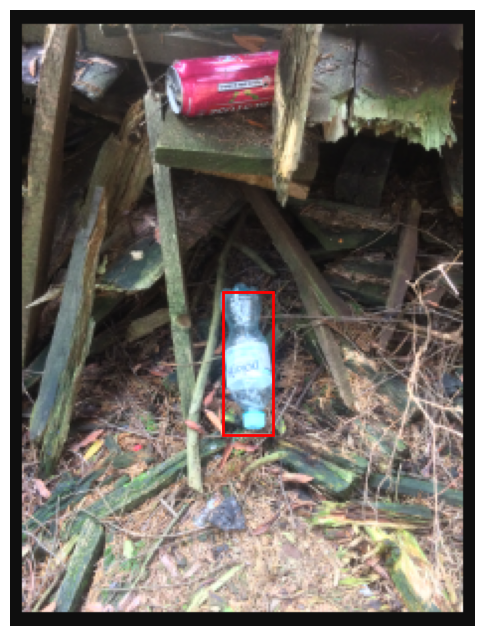

In [19]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
NUM_CLASSES = len(dataset.coco.getCatIds()) + 1

# Load best model
model = load_model_checkpoint('best_model.pth', NUM_CLASSES, device)

# Image inference
image_path = '/content/Screenshot 2025-07-22 153526.png'
boxes, labels, scores = predict_image(model, image_path, device, threshold=0.5)

# Visualize
visualize_predictions(image_path, boxes, labels, scores, category_names)


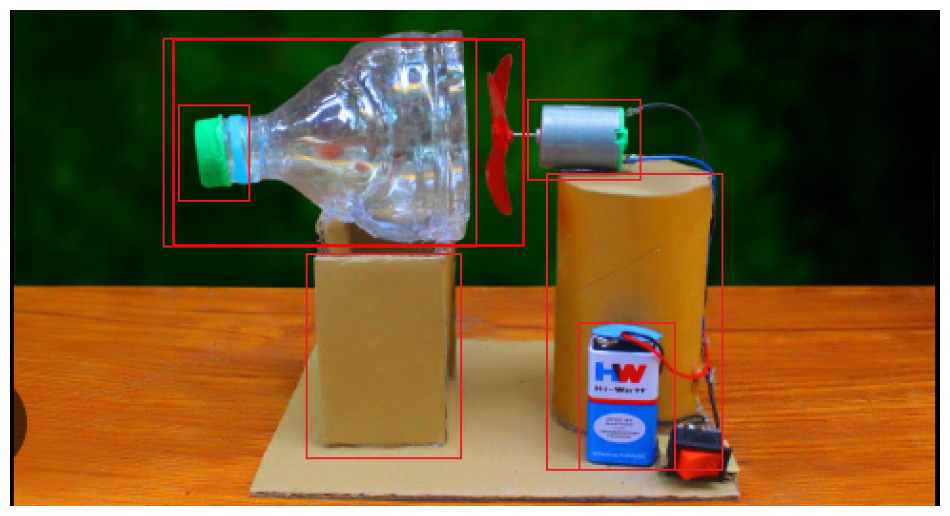

In [25]:
image_path = '/content/Screenshot 2025-06-04 200412.png'
boxes, labels, scores = predict_image(model, image_path, device, threshold=0.5)

# Visualize
visualize_predictions(image_path, boxes, labels, scores, category_names)

In [19]:
print(category_names)
print(labels)


{0: 'Aluminium foil', 1: 'Battery', 2: 'Aluminium blister pack', 3: 'Carded blister pack', 4: 'Other plastic bottle', 5: 'Clear plastic bottle', 6: 'Glass bottle', 7: 'Plastic bottle cap', 8: 'Metal bottle cap', 9: 'Broken glass', 10: 'Food Can', 11: 'Aerosol', 12: 'Drink can', 13: 'Toilet tube', 14: 'Other carton', 15: 'Egg carton', 16: 'Drink carton', 17: 'Corrugated carton', 18: 'Meal carton', 19: 'Pizza box', 20: 'Paper cup', 21: 'Disposable plastic cup', 22: 'Foam cup', 23: 'Glass cup', 24: 'Other plastic cup', 25: 'Food waste', 26: 'Glass jar', 27: 'Plastic lid', 28: 'Metal lid', 29: 'Other plastic', 30: 'Magazine paper', 31: 'Tissues', 32: 'Wrapping paper', 33: 'Normal paper', 34: 'Paper bag', 35: 'Plastified paper bag', 36: 'Plastic film', 37: 'Six pack rings', 38: 'Garbage bag', 39: 'Other plastic wrapper', 40: 'Single-use carrier bag', 41: 'Polypropylene bag', 42: 'Crisp packet', 43: 'Spread tub', 44: 'Tupperware', 45: 'Disposable food container', 46: 'Foam food container', 4

In [27]:
checkpoint = torch.load('best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
start_epoch = checkpoint['epoch'] + 1


In [28]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3, verbose=True
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


#Fine Tuning

In [ ]:
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    device=device,
    num_epochs=10
)


In [ ]:
from tqdm import tqdm

def evaluate_model(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    model.eval()
    tp, fp, fn = 0, 0, 0
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i, output in enumerate(outputs):
                pred_boxes = output['boxes'].cpu()
                pred_scores = output['scores'].cpu()
                pred_labels = output['labels'].cpu()

                gt_boxes = targets[i]['boxes'].cpu()
                gt_labels = targets[i]['labels'].cpu()

                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = pred_labels[keep]

                matched_gt = set()

                for pb, pl in zip(pred_boxes, pred_labels):
                    for idx, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                        iou = calculate_iou(pb, gb)
                        if iou >= iou_threshold and idx not in matched_gt and pl == gl:
                            tp += 1
                            matched_gt.add(idx)
                            break
                    else:
                        fp += 1
                fn += len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")
    return precision, recall


In [ ]:
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou


In [ ]:
precision, recall = evaluate_model(model, val_loader, device)


Evaluating: 100%|██████████| 75/75 [02:27<00:00,  1.97s/it]

Precision: 0.3643, Recall: 0.1126


In [21]:
#After fine tuning
precision, recall = evaluate_model(model, val_loader, device)

Evaluating: 100%|██████████| 75/75 [02:27<00:00,  1.97s/it]Precision: 0.6343, Recall: 0.5126


#Classification

In [62]:
import torch
import torchvision
import torchvision.transforms as T
import cv2
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt

#Load Faster R-CNN model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fasterrcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
fasterrcnn_model.load_state_dict(torch.load('fasterrcnn.pth', map_location=device))
fasterrcnn_model.to(device)
fasterrcnn_model.eval()

# Load Best Keras classifier model
classifier_model = load_model('/content/best_model (1).keras')
class_names = ['Food_Waste', 'Hazardous_Waste', 'Recyclable_Waste', 'Residual_Waste']


In [63]:
def detect_and_classify(image_path, detection_threshold=0.5, classify_threshold=0.5, save_dir='crops'):
    os.makedirs(save_dir, exist_ok=True)

    img = cv2.imread(image_path)
    assert img is not None, f"Image {image_path} not found."

    orig_img = img.copy()
    img_tensor = T.ToTensor()(img).to(device)
    with torch.no_grad():
        fasterrcnn_model.eval()
        outputs = fasterrcnn_model([img_tensor])[0]

    boxes = outputs['boxes'].cpu().numpy()
    scores = outputs['scores'].cpu().numpy()

    count = 0
    for i, score in enumerate(scores):
        if score < detection_threshold:
            continue

        box = boxes[i]
        x1, y1, x2, y2 = map(int, box)
        crop = img[y1:y2, x1:x2]
        crop_filename = os.path.join(save_dir, f'crop_{count}.jpg')
        cv2.imwrite(crop_filename, crop)
        print(f"Saved crop: {crop_filename}")
        img_resized = cv2.resize(crop, (224, 224))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_preprocessed = preprocess_input(img_rgb)
        img_preprocessed = np.expand_dims(img_preprocessed, axis=0)

        predictions = classifier_model.predict(img_preprocessed, verbose=0)
        predicted_class_idx = np.argmax(predictions)
        confidence = np.max(predictions)
        predicted_class = class_names[predicted_class_idx]

        if confidence >= classify_threshold:
            label = f"{predicted_class} ({confidence*100:.1f}%)"
            color = (0, 255, 0)
        else:
            label = f"Uncertain ({confidence*100:.1f}%)"
            color = (0, 0, 255)

        cv2.rectangle(orig_img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(orig_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        count += 1

    output_image_path = os.path.join(save_dir, 'detected_and_classified.jpg')
    cv2.imwrite(output_image_path, orig_img)
    print(f"Detection + Classification image saved at: {output_image_path}")

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detections with Classifications")
    plt.show()


Saved crop: crops/crop_0.jpg
Saved crop: crops/crop_1.jpg
Saved crop: crops/crop_2.jpg
Saved crop: crops/crop_3.jpg
Detection + Classification image saved at: crops/detected_and_classified.jpg


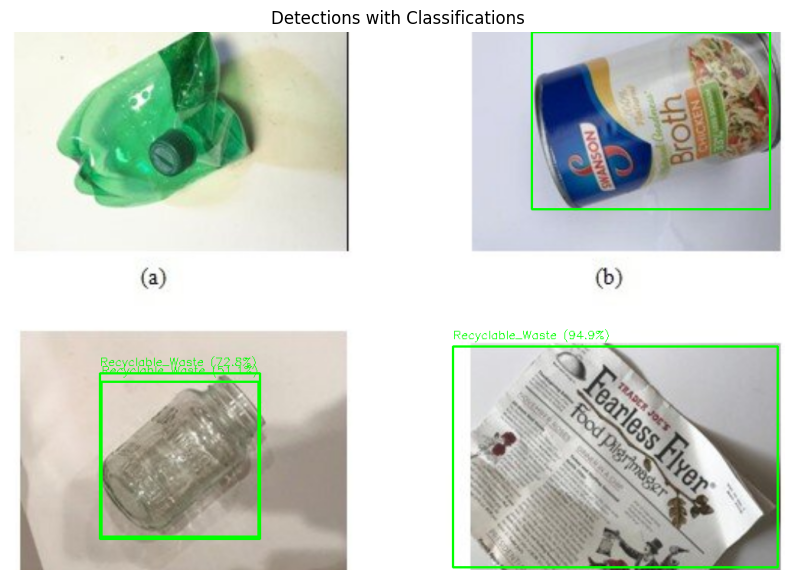

In [64]:
from tensorflow.keras.models import load_model
image_path = '/content/Screenshot 2025-06-04 170320.png'

detect_and_classify(image_path, detection_threshold=0.5, classify_threshold=0.4, save_dir='crops')

